In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image

ModuleNotFoundError: No module named 'cv2'

In [ ]:
# Display imagem 10x10 pixels
Image(filename='checkerboard_18x18.png')

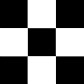

In [ ]:
Image(filename='checkerboard_84x84.jpg')

# <font style="color:black">Leitura de imagens usando OpenCV</font>

O OpenCV permite a leitura de diferentes tipos de imagens (JPG, PNG, etc.). Você pode carregar imagens em tons de cinza, imagens coloridas ou imagens com canal alfa. Ele usa a função **`cv2.imread()`**, que tem a seguinte sintaxe:

### <font color="green">Function Syntax </font>
``` python
retval = cv2.imread( filename[, flags] )
```

`retval`: A imagem é exibida se o carregamento for bem-sucedido. Caso contrário, será `None`. Isso pode ocorrer se o nome do arquivo estiver incorreto ou se o arquivo estiver corrompido.

A função possui **1 argumento de entrada obrigatório** e uma flag opcional:

1. `filename`: Este pode ser um caminho **absoluto** ou **relativo**. Este é um **argumento obrigatório**.
2. `Flags`: Esses sinalizadores são usados ​​para ler uma imagem em um formato específico (por exemplo, escala de cinza/colorido/com canal alfa). Este é um **argumento opcional** com um valor padrão de `cv2.IMREAD_COLOR` ou `1`, que carrega a imagem como uma imagem colorida.

Antes de prosseguirmos com alguns exemplos, vamos também dar uma olhada em algumas das `flags` disponíveis.

**Flags**
1. **`cv2.IMREAD_GRAYSCALE`** ou **`0`**: Carrega a imagem em modo escala de cinza.
2. **`cv2.IMREAD_COLOR`** ou **`1`**: Carrega uma imagem colorida. Qualquer transparência da imagem será ignorada. É a flag padrão.
3. **`cv2.IMREAD_UNCHANGED`** ou **`-1`**: Carrega a imagem como está, incluindo o canal alfa.


### <font color="green">OpenCV Documentation</font>

**`Imread:`** https://docs.opencv.org/4.5.1/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56

**`ImreadModes:`** https://docs.opencv.org/4.5.1/d8/d6a/group__imgcodecs__flags.html#ga61d9b0126a3e57d9277ac48327799c80

In [ ]:
# Read image as gray scale.
cb_img = cv.imread("checkerboard_18x18.png",0)

# Print the image data (pixel values), element of a 2D numpy array.
# Each pixel value is 8-bits [0,255]
print(cb_img)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

## Atributos da imagem

In [ ]:
#tamanho da imagem
print("Image size is", cb_img.shape)

print("Data type of image is", cb_img.dtype)

Image size is (18, 18)
Data type of image is uint8


## Display imagem usando matplotlib

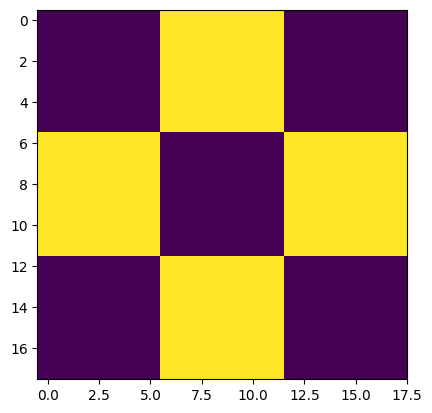

In [ ]:
plt.imshow(cb_img)

## O que aconteceu?

Embora a imagem tenha sido lida como uma imagem em tons de cinza, ela não será necessariamente exibida em tons de cinza ao usar `imshow()`. O matplotlib usa mapas de cores diferentes e é possível que o mapa de cores para tons de cinza não esteja definido.

In [ ]:
plt.imshow(cb_img, cmap='gray')

## Outro exemplo

In [ ]:
# Read image as gray scale.
cb_img_fuzzy = cv.imread("checkerboard_fuzzy_18x18.jpg",0)

# print image
print(cb_img_fuzzy)

# Display image.
plt.imshow(cb_img_fuzzy,cmap='gray')

## Trabalhando com Imagens Coloridas
Até agora, temos usado imagens em tons de cinza em nossa discussão. Vamos agora discutir imagens coloridas.

In [ ]:
# Read and display Coca-Cola logo.
Image("coca-cola-logo.png")

## Ler e exibir imagem colorida
Vamos ler uma imagem colorida e verificar os parâmetros. Observe as dimensões da imagem.

In [ ]:
# Read in image
coke_img = cv.imread("coca-cola-logo.png",1)

# print the size  of image
print("Image size is ", coke_img.shape)

# print data-type of image
print("Data type of image is ", coke_img.dtype)

print("")

## Display Imagem

In [ ]:
plt.imshow(coke_img)

A cor exibida acima é diferente da imagem real. Isso ocorre porque o matplotlib espera a imagem no formato RGB, enquanto o OpenCV armazena imagens no formato BGR. Portanto, para uma exibição correta, precisamos inverter os canais da imagem. Discutiremos os canais nas seções a seguir.

In [ ]:
coke_img_channels_reversed = coke_img[:, :, ::-1]
plt.imshow(coke_img_channels_reversed)

## Dividindo e Unindo Canais de Cor

**`cv2.split()`** Divide um array multicanal em vários arrays de canal único.

**`cv2.merge()`** Unir vários arrays para criar um único array multicanal. Todas as matrizes de entrada devem ter o mesmo tamanho.

### <font style="color:rgb(8,133,37)">Documentação do OpenCV</font>

https://docs.opencv.org/4.5.1/d2/de8/group__core__array.html#ga0547c7fed86152d7e9d0096029c8518a

In [ ]:
# Split the image into the B,G,R components
img_NZ_bgr = cv.imread("New_Zealand_Lake.jpg",cv.IMREAD_COLOR)
# Dividindo entre os componentes B, G e R,  cada uma dessas variáveis representa uma 
# matriz numpy 2D que contém a intencidade dos pixels para esses canais de cores
b,g,r = cv.split(img_NZ_bgr)

# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(r,cmap='gray');plt.title("Red Channel")
plt.subplot(142);plt.imshow(g,cmap='gray');plt.title("Green Channel")
plt.subplot(143);plt.imshow(b,cmap='gray');plt.title("Blue Channel")

# Merge the individual channels into a BGR image
imgMerged = cv.merge((b,g,r))
# Show the merged output
plt.subplot(144);plt.imshow(imgMerged[:,:,::-1]);plt.title("Merged Output")

## Convertendo para diferentes espaços de cores

**`cv2.cvtColor()`** Converte uma imagem de um espaço de cores para outro. A função converte uma imagem de entrada de um espaço de cores para outro. No caso de uma transformação de/para o espaço de cores RGB, a ordem dos canais deve ser especificada explicitamente (RGB ou BGR). Observe que o formato de cor padrão no OpenCV é frequentemente chamado de RGB, mas na verdade é BGR (os bytes são invertidos). Portanto, o primeiro byte em uma imagem colorida padrão (24 bits) será um componente Azul de 8 bits, o segundo byte será Verde e o terceiro byte será Vermelho. O quarto, quinto e sexto bytes seriam então o segundo pixel (Azul, depois Verde, depois Vermelho) e assim por diante.

### <font style="color:rgb(8,133,37)">Sintaxe da Função</font>
``` python
dst = cv2.cvtColor( src, code )
```

`dst`: É a imagem de saída com o mesmo tamanho e profundidade que `src`.

A função possui **2 argumentos obrigatórios**:

1. Imagem de entrada `src`: 8 bits sem sinal, 16 bits sem sinal (CV_16UC...), ou ponto flutuante de precisão simples.

2. Código de conversão de espaço de cores `code` (consulte ColorConversionCodes).

### <font style="color:rgb(8,133,37)">Documentação do OpenCV</font>

**`cv2.cvtColor:`** https://docs.opencv.org/3.4/d8/d01/group__imgproc__color__conversions.html#ga397ae87e1288a81d2363b61574eb8cab
**`ColorConversionCodes:`** https://docs.opencv.org/4.5.1/d8/d01/group__imgproc__color__conversions.html#ga4e0972be5de079fed4e3a10e24ef5ef0

### Mudando de BGR para RGB

In [ ]:
img_NZ_rgb = cv.cvtColor(img_NZ_bgr, cv.COLOR_BGR2RGB)
plt.imshow(img_NZ_rgb)

### Mudando para o espaço de cores HSV

In [ ]:
img_hsv = cv.cvtColor(img_NZ_bgr, cv.COLOR_BGR2HSV)
# Split the image into the B,G,R components
# H representa  asaturação da imagem
# S saturação da cor da imagem, representa a intensidade da cor
# V representa o valor, pode ser pensado como sendo quão claro ou escuro são as partes da imagem
h,s,v = cv.split(img_hsv)

# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h,cmap='gray');plt.title("H Channel");
plt.subplot(142);plt.imshow(s,cmap='gray');plt.title("S Channel");
plt.subplot(143);plt.imshow(v,cmap='gray');plt.title("V Channel");
plt.subplot(144);plt.imshow(img_NZ_rgb);plt.title("Original");


## Modificando canal individual

In [ ]:
h_new = h+10
img_NZ_merged = cv.merge((h_new,s,v))
img_NZ_rgb = cv.cvtColor(img_NZ_merged, cv.COLOR_HSV2RGB)

# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h,cmap='gray');plt.title("H Channel");
plt.subplot(142);plt.imshow(s,cmap='gray');plt.title("S Channel");
plt.subplot(143);plt.imshow(v,cmap='gray');plt.title("V Channel");
plt.subplot(144);plt.imshow(img_NZ_rgb);plt.title("Modified");

## Salvando Imagens

Salvar uma imagem é tão simples quanto lê-la no OpenCV. Usamos a função **`cv2.imwrite()`** com dois argumentos. O primeiro é o nome do arquivo e o segundo é o objeto da imagem.

A função `imwrite` salva a imagem no arquivo especificado. O formato da imagem é escolhido com base na extensão do nome do arquivo (consulte `cv::imread` para a lista de extensões). Em geral, apenas imagens de 8 bits de canal único ou de 3 canais (com ordem de canais 'BGR') podem ser salvas usando esta função (consulte a documentação do OpenCV para obter mais detalhes).

### <font style="color:rgb(8,133,37)">Sintaxe da Função</font>
``` python
cv2.imwrite( filename, img[, params] )
```

A função possui **2 argumentos obrigatórios**:

1. `filename`: Este pode ser um caminho **absoluto** ou **relativo**.

2. `img`: Imagem ou imagens a serem salvas.

### <font style="color:rgb(8,133,37)">Documentação do OpenCV</font>

**`Imwrite:`** https://docs.opencv.org/4.5.1/d4/da8/group__imgcodecs.html#gabbc7ef1aa2edfaa87772f1202d67e0ce
**`ImwriteFlags:`** https://docs.opencv.org/4.5.1/d8/d6a/group__imgcodecs__flags.html#ga292d81be8d76901bff7988d18d2b42ac

In [ ]:
cv.imwrite("New_Zealand_Lake_SAVED.png", img_NZ_bgr)

Image(filename='New_Zealand_Lake_SAVED.png') 

In [ ]:
img_NZ_bgr = cv.imread("New_Zealand_Lake_SAVED.png", cv.IMREAD_COLOR)
print("img_NZ_bgr shape is: ", img_NZ_bgr.shape)

# read the image as Grayscaled
img_NZ_gry = cv.imread("New_Zealand_Lake_SAVED.png", cv.IMREAD_GRAYSCALE)
print("img_NZ_gry shape is: ", img_NZ_gry.shape)